# Lunge Exercise — GCN Training Notebook

Two models trained end-to-end:
- **Stage detector** — 3 classes: I (Init/standing), M (Mid), D (Down)
- **Error detector** — 2 classes: C (Correct), L (Lean error)

Architecture: 3-layer GCNConv → flatten → FC head (same pattern as plank & bicep GCNs).

In [ ]:
# !pip install torch_geometric  # uncomment if not installed

In [1]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import networkx as nx
import pickle
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GCNConv

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    precision_recall_fscore_support,
)

# ── Reproducibility ───────────────────────────────────────────
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PALETTE = ["#667eea", "#764ba2", "#f093fb"]
C1, C2, C3, C4 = "#667eea", "#f093fb", "#4facfe", "#43e97b"

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 12,
    "axes.titlesize": 14, "axes.labelsize": 12,
    "axes.spines.top": False, "axes.spines.right": False,
})

print(f"PyTorch : {torch.__version__}")
print(f"Device  : {DEVICE}")
print(f"CUDA    : {torch.cuda.is_available()}")


PyTorch : 2.10.0+cu128
Device  : cuda
CUDA    : True


---
## 1. Graph Structure — 13-Node Lunge Skeleton

Lunges are a lower-body exercise. We keep all 13 landmarks from the CSV:
nose + shoulders (for torso tilt) + full leg chain both sides.
This gives the GCN spatial context from torso all the way to the feet.

In [3]:
# ── Landmark order — matches CSV column order exactly ─────────────────────
LANDMARKS = [
    "nose",
    "left_shoulder",    "right_shoulder",
    "left_hip",         "right_hip",
    "left_knee",        "right_knee",
    "left_ankle",       "right_ankle",
    "left_heel",        "right_heel",
    "left_foot_index",  "right_foot_index",
]
N_NODES = len(LANDMARKS)   # 13
N_FEATS = 4                # x, y, z, visibility

# Anatomical edges — kinematic chain from head to feet
SKELETON_EDGES = [
    # Head → torso
    ("nose",           "left_shoulder"),
    ("nose",           "right_shoulder"),
    # Collar
    ("left_shoulder",  "right_shoulder"),
    # Trunk
    ("left_shoulder",  "left_hip"),
    ("right_shoulder", "right_hip"),
    ("left_hip",       "right_hip"),
    # Legs
    ("left_hip",       "left_knee"),
    ("right_hip",      "right_knee"),
    ("left_knee",      "left_ankle"),
    ("right_knee",     "right_ankle"),
    # Cross-knee (captures asymmetry in lunge stance)
    ("left_hip",       "right_knee"),
    ("right_hip",      "left_knee"),
    # Feet
    ("left_ankle",     "left_heel"),
    ("right_ankle",    "right_heel"),
    ("left_ankle",     "left_foot_index"),
    ("right_ankle",    "right_foot_index"),
]

node_to_idx = {n: i for i, n in enumerate(LANDMARKS)}

# Bidirectional edge_index
src, dst = [], []
for u, v in SKELETON_EDGES:
    i, j = node_to_idx[u], node_to_idx[v]
    src += [i, j]
    dst += [j, i]
EDGE_INDEX = torch.tensor([src, dst], dtype=torch.long)

print(f"Nodes : {N_NODES}")
print(f"Edges : {len(SKELETON_EDGES)} undirected → {EDGE_INDEX.shape[1]} directed")
print(f"edge_index shape : {EDGE_INDEX.shape}")
print("\nLandmark → node index:")
for name, idx in node_to_idx.items():
    print(f"  {idx:2d}: {name}")


Nodes : 13
Edges : 16 undirected → 32 directed
edge_index shape : torch.Size([2, 32])

Landmark → node index:
   0: nose
   1: left_shoulder
   2: right_shoulder
   3: left_hip
   4: right_hip
   5: left_knee
   6: right_knee
   7: left_ankle
   8: right_ankle
   9: left_heel
  10: right_heel
  11: left_foot_index
  12: right_foot_index


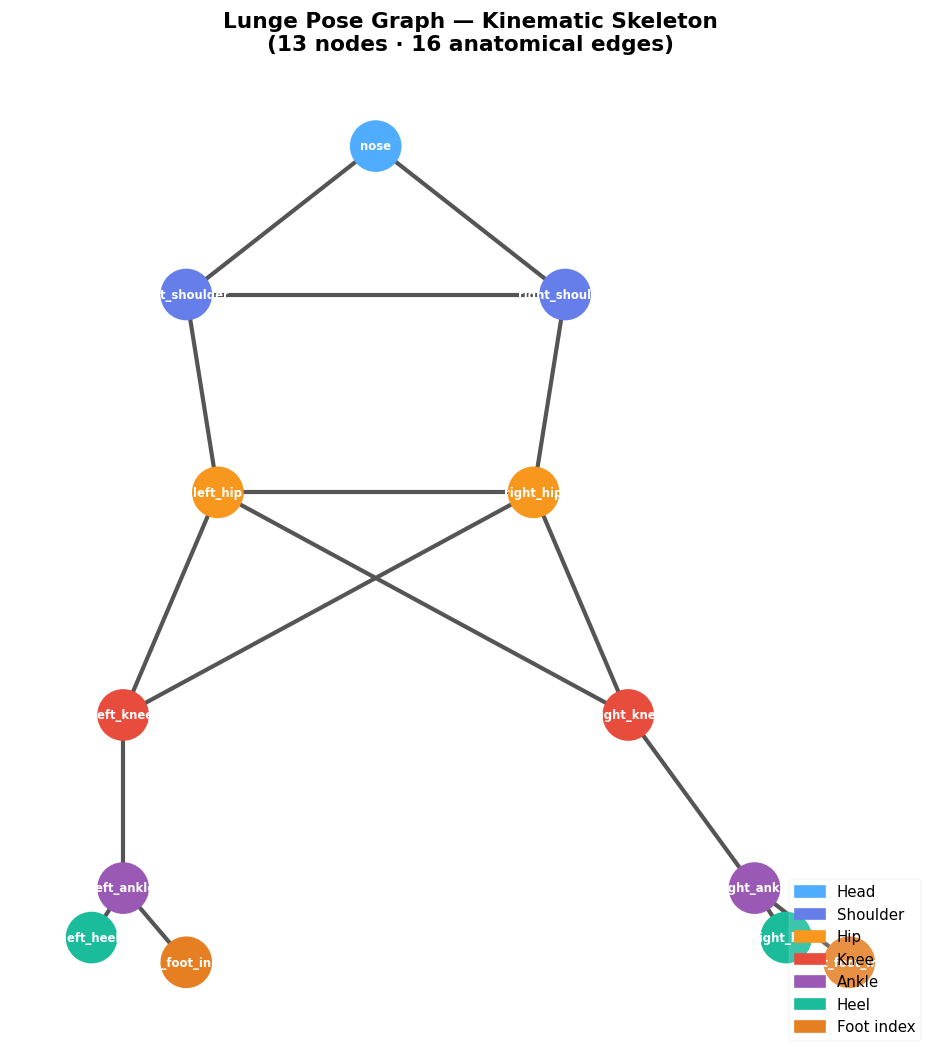

Saved: fig_01_lunge_pose_graph.png


In [4]:
# ── Visualise the lunge skeleton graph ────────────────────────────────────
G = nx.Graph()
G.add_nodes_from(LANDMARKS)
G.add_edges_from(SKELETON_EDGES)

# Anatomical layout — upright lunge position
pos = {
    "nose":             ( 0.0,  3.0),
    "left_shoulder":    (-0.6,  2.4),  "right_shoulder":   ( 0.6,  2.4),
    "left_hip":         (-0.5,  1.6),  "right_hip":        ( 0.5,  1.6),
    "left_knee":        (-0.8,  0.7),  "right_knee":       ( 0.8,  0.7),
    "left_ankle":       (-0.8,  0.0),  "right_ankle":      ( 1.2,  0.0),
    "left_heel":        (-0.9, -0.2),  "right_heel":       ( 1.3, -0.2),
    "left_foot_index":  (-0.6, -0.3),  "right_foot_index": ( 1.5, -0.3),
}

node_color_map = {
    "nose"           : C3,
    "left_shoulder"  : C1,  "right_shoulder"  : C1,
    "left_hip"       : "#f7971e", "right_hip"       : "#f7971e",
    "left_knee"      : "#e74c3c", "right_knee"      : "#e74c3c",
    "left_ankle"     : "#9b59b6", "right_ankle"     : "#9b59b6",
    "left_heel"      : "#1abc9c", "right_heel"      : "#1abc9c",
    "left_foot_index": "#e67e22", "right_foot_index": "#e67e22",
}
node_colors = [node_color_map[n] for n in LANDMARKS]

fig, ax = plt.subplots(figsize=(8, 9))
nx.draw_networkx_edges(G, pos, width=2.5, edge_color="#555", ax=ax)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=900, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=7, font_color="white",
                        font_weight="bold", ax=ax)
legend_items = [
    mpatches.Patch(color=C3,        label="Head"),
    mpatches.Patch(color=C1,        label="Shoulder"),
    mpatches.Patch(color="#f7971e", label="Hip"),
    mpatches.Patch(color="#e74c3c", label="Knee"),
    mpatches.Patch(color="#9b59b6", label="Ankle"),
    mpatches.Patch(color="#1abc9c", label="Heel"),
    mpatches.Patch(color="#e67e22", label="Foot index"),
]
ax.legend(handles=legend_items, loc="lower right", fontsize=9, framealpha=0.15)
ax.set_title(
    "Lunge Pose Graph — Kinematic Skeleton\n"
    f"(13 nodes · {len(SKELETON_EDGES)} anatomical edges)",
    fontsize=13, fontweight="bold"
)
ax.axis("off")
plt.tight_layout()
plt.savefig("fig_01_lunge_pose_graph.png", bbox_inches="tight")
plt.show()
print("Saved: fig_01_lunge_pose_graph.png")


---
## 2. Shared Utilities

Pose normalisation, dataset builder, model class, training/evaluation loops — defined once and reused by both stage and error models.

In [5]:
# ── Camera-invariant pose normalisation ──────────────────────────────────
def normalize_pose(df):
    """
    1. Subtract torso centre  → removes camera position offset
    2. Divide by torso size   → removes camera distance / body height
    Operates on all x/y/z columns; visibility is left unchanged.
    """
    df = df.copy()

    centre_x = (df["left_shoulder_x"] + df["right_shoulder_x"] +
                 df["left_hip_x"]      + df["right_hip_x"]) / 4
    centre_y = (df["left_shoulder_y"] + df["right_shoulder_y"] +
                 df["left_hip_y"]      + df["right_hip_y"]) / 4

    shoulder_mid_x = (df["left_shoulder_x"] + df["right_shoulder_x"]) / 2
    shoulder_mid_y = (df["left_shoulder_y"] + df["right_shoulder_y"]) / 2
    hip_mid_x      = (df["left_hip_x"]      + df["right_hip_x"])      / 2
    hip_mid_y      = (df["left_hip_y"]      + df["right_hip_y"])      / 2

    torso_size = np.sqrt(
        (shoulder_mid_x - hip_mid_x) ** 2 +
        (shoulder_mid_y - hip_mid_y) ** 2
    ) + 1e-6

    for lm in LANDMARKS:
        df[f"{lm}_x"] = (df[f"{lm}_x"] - centre_x) / torso_size
        df[f"{lm}_y"] = (df[f"{lm}_y"] - centre_y) / torso_size
        df[f"{lm}_z"] =  df[f"{lm}_z"]              / torso_size
        # visibility unchanged

    return df


In [6]:
# ── Graph dataset builder ─────────────────────────────────────────────────
def build_graph_dataset(X_np, y_np, edge_index):
    """Convert flat [N, N_NODES*N_FEATS] array into PyG Data list."""
    dataset = []
    for i in range(len(X_np)):
        x = torch.tensor(X_np[i].reshape(N_NODES, N_FEATS), dtype=torch.float)
        y = torch.tensor(y_np[i], dtype=torch.long)
        dataset.append(Data(x=x, edge_index=edge_index, y=y))
    return dataset


In [7]:
# ── LungeGCN — 3-layer GCN with flatten head ─────────────────────────────
class LungeGCN(nn.Module):
    """
    3-layer GCNConv → flatten → FC classification head.
    Flatten (not global_mean_pool) preserves node identity,
    which is critical for a fixed-size pose graph.

    For stage : n_classes=3  (I, M, D)
    For error  : n_classes=2  (C, L)

    Flatten head input: 13 nodes × 32 out_feats = 416
    """
    def __init__(self, in_feats=4, hidden=64, out_feats=32,
                 n_classes=3, dropout=0.4):
        super().__init__()
        self.out_feats = out_feats

        self.conv1 = GCNConv(in_feats, hidden)
        self.conv2 = GCNConv(hidden,   hidden)
        self.conv3 = GCNConv(hidden,   out_feats)

        self.bn1 = nn.BatchNorm1d(hidden)
        self.bn2 = nn.BatchNorm1d(hidden)
        self.bn3 = nn.BatchNorm1d(out_feats)

        # 13 × 32 = 416
        self.head = nn.Sequential(
            nn.Linear(N_NODES * out_feats, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, n_classes),
        )
        self.dropout = dropout

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.bn3(self.conv3(x, edge_index)))

        # Flatten — preserves all 13 node embeddings separately
        batch_size = batch.max().item() + 1
        x = x.view(batch_size, N_NODES * self.out_feats)   # [B, 416]

        return self.head(x)

    def embed(self, data):
        """Return flattened node embeddings (before head) for visualisation."""
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        batch_size = batch.max().item() + 1
        return x.view(batch_size, N_NODES * self.out_feats)


In [8]:
# ── Training & evaluation loops ───────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out  = model(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        correct    += (out.argmax(1) == batch.y).sum().item()
        total      += batch.num_graphs
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_probs, all_labels = [], [], []
    for batch in loader:
        batch = batch.to(device)
        out   = model(batch)
        loss  = criterion(out, batch.y)
        total_loss += loss.item() * batch.num_graphs
        probs = F.softmax(out, dim=1)
        pred  = out.argmax(dim=1)
        correct += (pred == batch.y).sum().item()
        total   += batch.num_graphs
        all_preds.extend(pred.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(batch.y.cpu().numpy())
    return (total_loss / total, correct / total,
            np.array(all_preds), np.array(all_probs), np.array(all_labels))


def train_model(model, train_loader, test_loader, name="LungeGCN", epochs=120):
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=10)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_acc, best_state = 0.0, None

    print(f"Training {name} on {DEVICE} ...")
    print(f"{'Epoch':>6} {'TrainLoss':>10} {'ValLoss':>10} {'TrainAcc':>10} {'ValAcc':>10}")
    print("-" * 55)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, DEVICE)
        va_loss, va_acc, _, _, _ = evaluate(model, test_loader, criterion, DEVICE)
        scheduler.step(va_loss)

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc)
        history["val_acc"].append(va_acc)

        if va_acc > best_acc:
            best_acc  = va_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if epoch % 10 == 0 or epoch == 1:
            print(f"{epoch:>6} {tr_loss:>10.4f} {va_loss:>10.4f} "
                  f"{tr_acc*100:>9.2f}% {va_acc*100:>9.2f}%")

    model.load_state_dict(best_state)
    print(f"\n✅  Best val accuracy: {best_acc*100:.2f}%")
    return history


---
## 3. Stage Detector — 3-Class (I / M / D)

Classifies the lunge phase: **I** = standing/init, **M** = mid descent, **D** = full depth.

In [12]:
# ── Load stage datasets ───────────────────────────────────────────────────
stage_train_df = pd.read_csv("stage.train.csv")
stage_test_df  = pd.read_csv("stage.test.csv")

stage_train_df = stage_train_df.reset_index(drop=True)
stage_test_df  = stage_test_df.reset_index(drop=True)

print(f"Stage Train : {len(stage_train_df):,} samples")
print(f"Stage Test  : {len(stage_test_df):,} samples")
print(f"\nTrain label counts:\n{stage_train_df['label'].value_counts()}")
print(f"\nTest  label counts:\n{stage_test_df['label'].value_counts()}")


Stage Train : 24,244 samples
Stage Test  : 1,205 samples

Train label counts:
label
D    8232
M    8148
I    7864
Name: count, dtype: int64

Test  label counts:
label
D    416
I    402
M    387
Name: count, dtype: int64


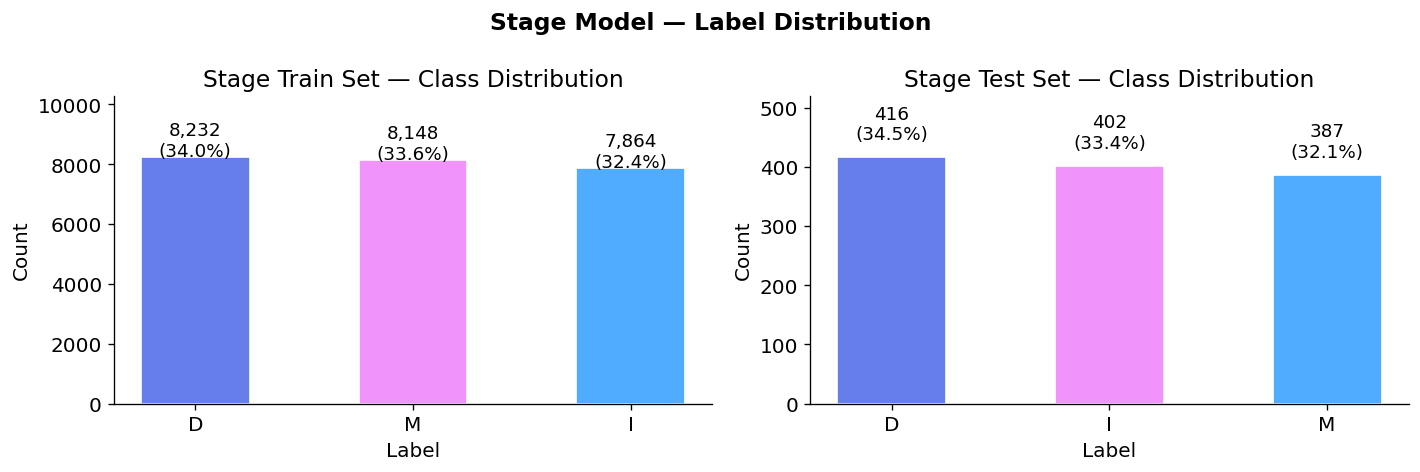

In [13]:
# ── Class distribution ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (df_plot, title) in zip(axes, [
        (stage_train_df, "Stage Train Set"),
        (stage_test_df,  "Stage Test Set")]):
    counts = df_plot["label"].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=[C1, C2, C3], edgecolor="white", width=0.5)
    ax.set_title(f"{title} — Class Distribution")
    ax.set_xlabel("Label"); ax.set_ylabel("Count")
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f"{val:,}\n({val/len(df_plot)*100:.1f}%)",
                ha="center", fontsize=11)
    ax.set_ylim(0, counts.max() * 1.25)
plt.suptitle("Stage Model — Label Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_02_stage_class_distribution.png", bbox_inches="tight")
plt.show()


In [14]:
# ── Normalise + encode + scale (stage) ───────────────────────────────────
stage_train_norm = normalize_pose(stage_train_df)
stage_test_norm  = normalize_pose(stage_test_df)

stage_le = LabelEncoder()
y_stage_train = stage_le.fit_transform(stage_train_norm["label"].values)
y_stage_test  = stage_le.transform(stage_test_norm["label"].values)
N_STAGE_CLASSES = len(stage_le.classes_)

print("Stage label encoding:", dict(zip(stage_le.classes_, stage_le.transform(stage_le.classes_))))
print("Classes:", stage_le.classes_.tolist(), "| N_CLASSES:", N_STAGE_CLASSES)

FEATURE_COLS = [c for c in stage_train_norm.columns if c != "label"]
stage_scaler = StandardScaler()
X_stage_train = stage_scaler.fit_transform(stage_train_norm[FEATURE_COLS].values)
X_stage_test  = stage_scaler.transform(stage_test_norm[FEATURE_COLS].values)

print(f"\nTrain — mean: {X_stage_train.mean():+.5f} | std: {X_stage_train.std():.5f}")
print(f"Test  — mean: {X_stage_test.mean():+.5f}  | std: {X_stage_test.std():.5f}")


Stage label encoding: {'D': np.int64(0), 'I': np.int64(1), 'M': np.int64(2)}
Classes: ['D', 'I', 'M'] | N_CLASSES: 3

Train — mean: +0.00000 | std: 1.00000
Test  — mean: -0.03689  | std: 1.12513


In [15]:
# ── Build PyG datasets (stage) ────────────────────────────────────────────
BATCH_SIZE = 256

stage_train_dataset = build_graph_dataset(X_stage_train, y_stage_train, EDGE_INDEX)
stage_test_dataset  = build_graph_dataset(X_stage_test,  y_stage_test,  EDGE_INDEX)

stage_train_loader = DataLoader(stage_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
stage_test_loader  = DataLoader(stage_test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

s = stage_train_dataset[0]
print("Single graph object:")
print(f"  data.x          : {s.x.shape}    → [{N_NODES} nodes, {N_FEATS} features]")
print(f"  data.edge_index : {s.edge_index.shape}   → [2, {EDGE_INDEX.shape[1]} directed edges]")
print(f"  data.y          : {s.y.item()}")
print(f"\nTrain batches : {len(stage_train_loader)}")
print(f"Test  batches : {len(stage_test_loader)}")


Single graph object:
  data.x          : torch.Size([13, 4])    → [13 nodes, 4 features]
  data.edge_index : torch.Size([2, 32])   → [2, 32 directed edges]
  data.y          : 2

Train batches : 95
Test  batches : 5


In [16]:
# ── Train Stage GCN ───────────────────────────────────────────────────────
EPOCHS = 120

stage_model = LungeGCN(n_classes=N_STAGE_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in stage_model.parameters() if p.requires_grad)
print(f"Model architecture:\n{stage_model}")
print(f"\nTotal trainable parameters: {total_params:,}")


Model architecture:
LungeGCN(
  (conv1): GCNConv(4, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 32)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (head): Sequential(
    (0): Linear(in_features=416, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.4, inplace=False)
    (6): Linear(in_features=64, out_features=3, bias=True)
  )
)

Total trainable parameters: 68,707


In [17]:
stage_history = train_model(
    stage_model, stage_train_loader, stage_test_loader,
    name="LungeGCN-Stage", epochs=EPOCHS
)


Training LungeGCN-Stage on cuda ...
 Epoch  TrainLoss    ValLoss   TrainAcc     ValAcc
-------------------------------------------------------
     1     0.2026     0.0774     92.70%     97.18%
    10     0.0288     0.0892     99.19%     96.60%
    20     0.0234     0.1001     99.34%     96.18%
    30     0.0214     0.1125     99.34%     95.35%
    40     0.0203     0.1083     99.37%     95.60%
    50     0.0204     0.1112     99.43%     95.44%
    60     0.0186     0.1231     99.46%     95.27%
    70     0.0190     0.1180     99.47%     95.27%
    80     0.0188     0.1136     99.42%     95.44%
    90     0.0199     0.1294     99.47%     95.02%
   100     0.0182     0.1183     99.47%     95.19%
   110     0.0196     0.1196     99.48%     95.35%
   120     0.0193     0.1148     99.46%     95.44%

✅  Best val accuracy: 97.18%


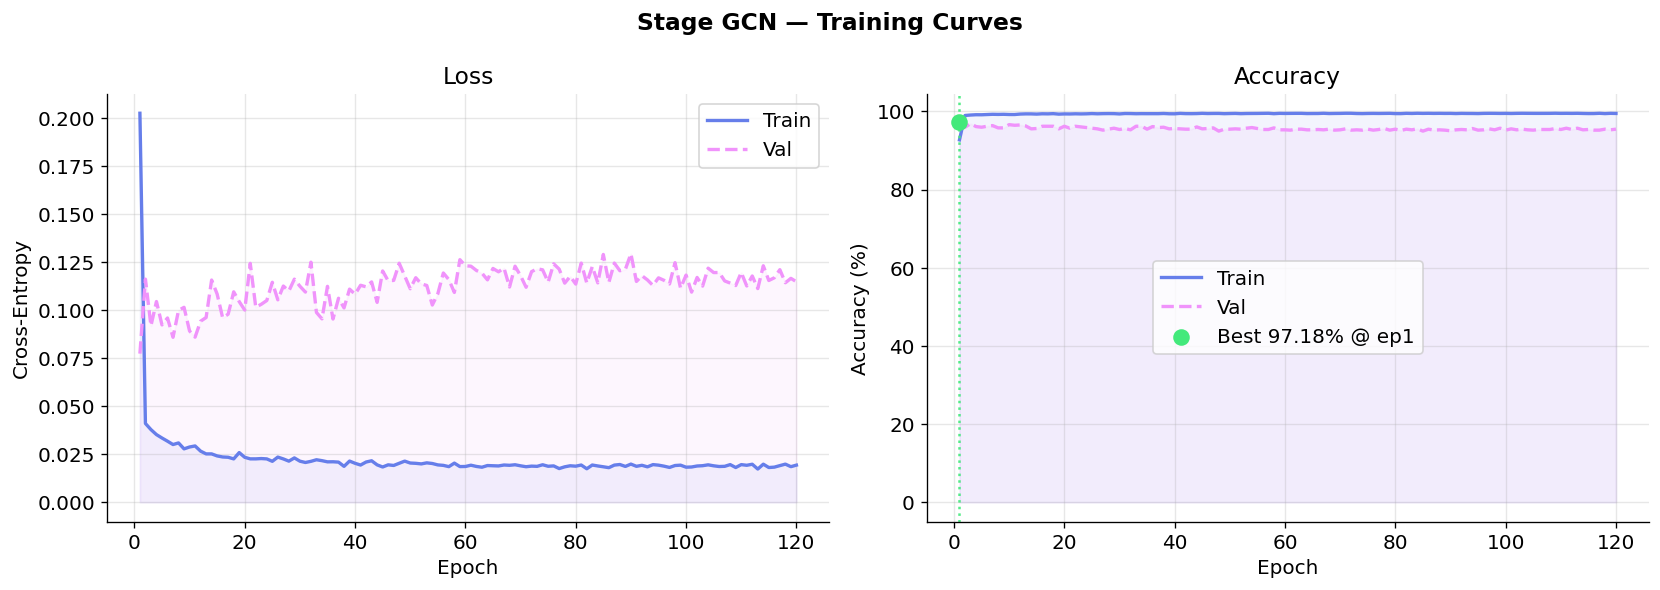

Saved: eval_stage_01_training_curves.png


In [18]:
# ── Training curves (stage) ───────────────────────────────────────────────
epochs_range = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Stage GCN — Training Curves", fontsize=14, fontweight="bold")

axes[0].plot(epochs_range, stage_history["train_loss"], color=C1, lw=2, label="Train")
axes[0].plot(epochs_range, stage_history["val_loss"],   color=C2, lw=2, ls="--", label="Val")
axes[0].fill_between(epochs_range, stage_history["train_loss"], alpha=0.08, color=C1)
axes[0].fill_between(epochs_range, stage_history["val_loss"],   alpha=0.08, color=C2)
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-Entropy")
axes[0].legend()

train_acc_pct = [a*100 for a in stage_history["train_acc"]]
val_acc_pct   = [a*100 for a in stage_history["val_acc"]]
axes[1].plot(epochs_range, train_acc_pct, color=C1, lw=2, label="Train")
axes[1].plot(epochs_range, val_acc_pct,   color=C2, lw=2, ls="--", label="Val")
axes[1].fill_between(epochs_range, train_acc_pct, alpha=0.08, color=C1)
axes[1].fill_between(epochs_range, val_acc_pct,   alpha=0.08, color=C2)

best_ep  = int(np.argmax(val_acc_pct)) + 1
best_val = max(val_acc_pct)
axes[1].axvline(best_ep, color=C4, lw=1.5, ls=":", alpha=0.9)
axes[1].scatter(best_ep, best_val, color=C4, s=80, zorder=5,
                label=f"Best {best_val:.2f}% @ ep{best_ep}")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("eval_stage_01_training_curves.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: eval_stage_01_training_curves.png")


In [19]:
# ── Stage model evaluation on test set ───────────────────────────────────
criterion_eval = nn.CrossEntropyLoss()
_, stage_acc, stage_preds, stage_probs, stage_true = evaluate(
    stage_model, stage_test_loader, criterion_eval, DEVICE
)

stage_metrics = {
    "Accuracy" : accuracy_score(stage_true, stage_preds),
    "F1 Score" : f1_score(stage_true, stage_preds, average="macro"),
    "Precision": precision_score(stage_true, stage_preds, average="macro"),
    "Recall"   : recall_score(stage_true, stage_preds, average="macro"),
}

print("Stage GCN — Test Set Metrics:")
for k, v in stage_metrics.items():
    print(f"  {k:12s}: {v*100:.2f}%")

print("\n── Full Classification Report ──")
print(classification_report(stage_true, stage_preds,
      target_names=[f"{c}" for c in stage_le.classes_]))


Stage GCN — Test Set Metrics:
  Accuracy    : 97.18%
  F1 Score    : 97.12%
  Precision   : 97.24%
  Recall      : 97.11%

── Full Classification Report ──
              precision    recall  f1-score   support

           D       0.98      0.99      0.98       416
           I       0.95      1.00      0.97       402
           M       0.98      0.93      0.95       387

    accuracy                           0.97      1205
   macro avg       0.97      0.97      0.97      1205
weighted avg       0.97      0.97      0.97      1205



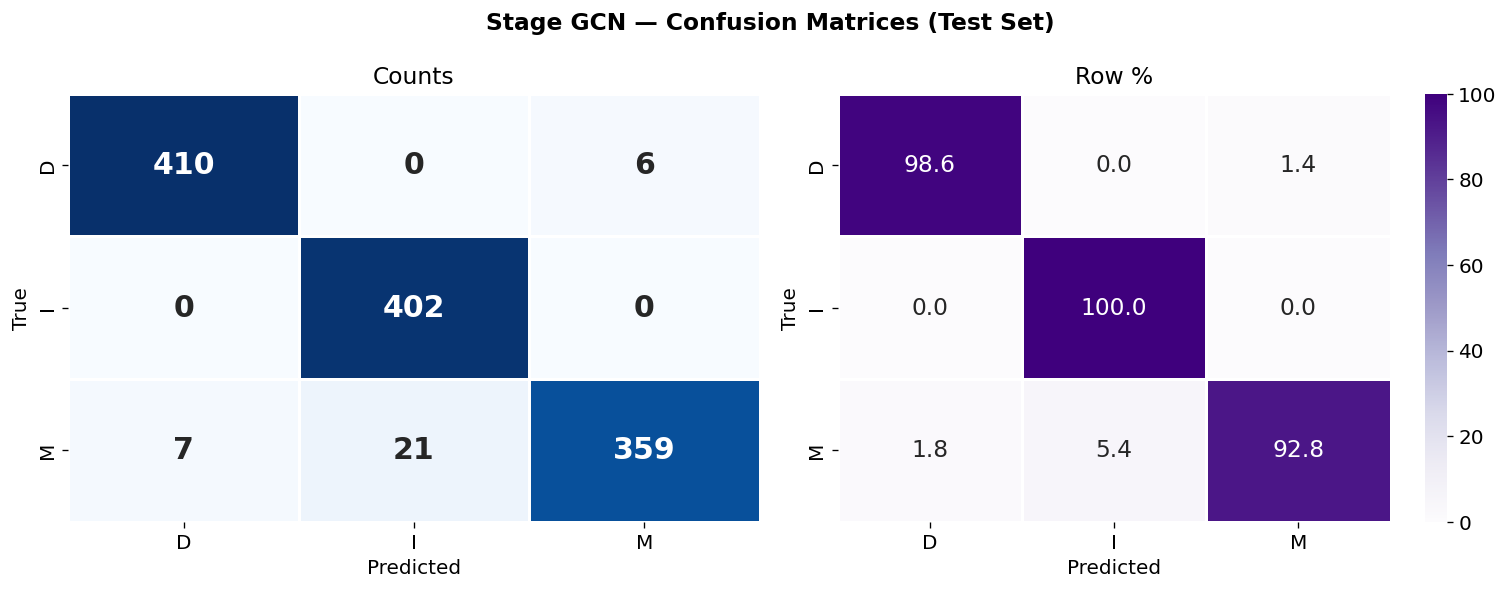

Saved: eval_stage_02_confusion_matrix.png


In [20]:
# ── Confusion matrix (stage) ──────────────────────────────────────────────
class_names = stage_le.classes_
cm     = confusion_matrix(stage_true, stage_preds)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Stage GCN — Confusion Matrices (Test Set)", fontsize=14, fontweight="bold")

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1.5, ax=axes[0], cbar=False,
            annot_kws={"size": 18, "weight": "bold"})
axes[0].set_title("Counts"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Purples",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=1.5, ax=axes[1], cbar=True,
            annot_kws={"size": 14})
axes[1].set_title("Row %"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig("eval_stage_02_confusion_matrix.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: eval_stage_02_confusion_matrix.png")


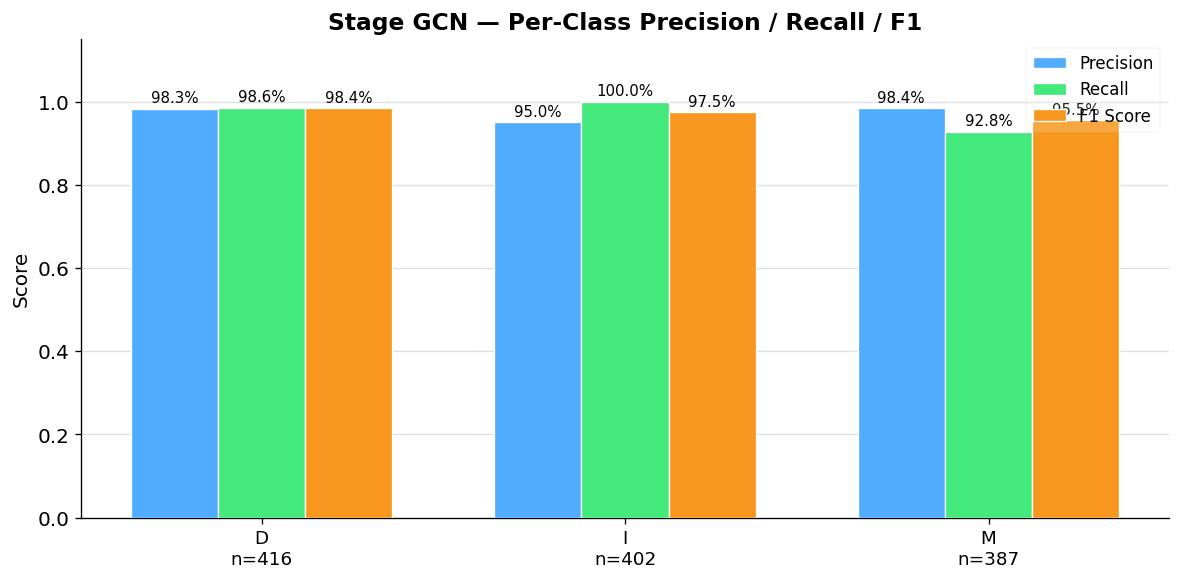

Saved: eval_stage_03_per_class_metrics.png


In [21]:
# ── Per-class Precision / Recall / F1 (stage) ────────────────────────────
prec, rec, f1_vals, support = precision_recall_fscore_support(
    stage_true, stage_preds, labels=list(range(N_STAGE_CLASSES)))

x = np.arange(N_STAGE_CLASSES)
w = 0.24
colors = ["#4facfe", "#43e97b", "#f7971e"]

fig, ax = plt.subplots(figsize=(10, 5))
for bars_data, offset, color, label in [
    (prec,    -w, colors[0], "Precision"),
    (rec,      0, colors[1], "Recall"),
    (f1_vals, +w, colors[2], "F1 Score"),
]:
    bars = ax.bar(x + offset, bars_data, w, color=color,
                  edgecolor="white", linewidth=0.8, label=label, zorder=3)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f"{bar.get_height()*100:.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{stage_le.classes_[i]}\nn={support[i]}" for i in range(N_STAGE_CLASSES)],
    fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Stage GCN — Per-Class Precision / Recall / F1", fontweight="bold")
ax.legend(fontsize=10, framealpha=0.15)
ax.grid(axis="y", alpha=0.4, zorder=0)

plt.tight_layout()
plt.savefig("eval_stage_03_per_class_metrics.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: eval_stage_03_per_class_metrics.png")


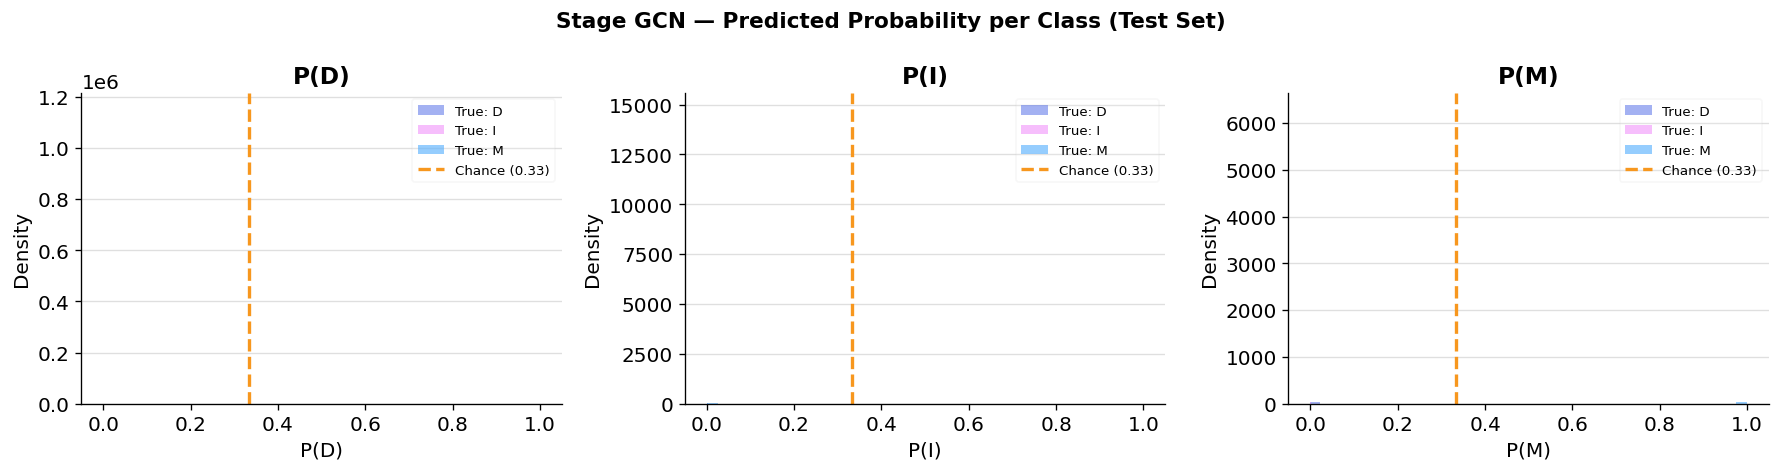

Saved: eval_stage_04_prob_distributions.png


In [22]:
# ── Per-class probability distributions (stage) ───────────────────────────
class_names_full = {i: c for i, c in enumerate(stage_le.classes_)}
row_colors = [C1, C2, C3]

fig, axes = plt.subplots(1, N_STAGE_CLASSES, figsize=(15, 4))
fig.suptitle("Stage GCN — Predicted Probability per Class (Test Set)",
             fontsize=13, fontweight="bold")

for cls_idx in range(N_STAGE_CLASSES):
    ax = axes[cls_idx]
    for true_cls, color in enumerate(row_colors):
        mask = stage_true == true_cls
        ax.hist(stage_probs[mask, cls_idx], bins=40, alpha=0.6,
                color=color, label=f"True: {stage_le.classes_[true_cls]}",
                edgecolor="none", density=True)
    ax.axvline(1/N_STAGE_CLASSES, color="#f7971e", lw=2, ls="--",
               label=f"Chance ({1/N_STAGE_CLASSES:.2f})")
    ax.set_xlabel(f"P({stage_le.classes_[cls_idx]})")
    ax.set_ylabel("Density")
    ax.set_title(f"P({class_names_full[cls_idx]})", fontweight="bold")
    ax.legend(fontsize=8, framealpha=0.15)
    ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("eval_stage_04_prob_distributions.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: eval_stage_04_prob_distributions.png")


In [23]:
# ── Save Stage model artifacts ────────────────────────────────────────────
torch.save(stage_model.state_dict(), "lunge_stage_gcn.pth")
print("✅  Saved: lunge_stage_gcn.pth")

with open("lunge_stage_gcn_scaler.pkl", "wb") as f:
    pickle.dump(stage_scaler, f)
print("✅  Saved: lunge_stage_gcn_scaler.pkl")

with open("lunge_stage_gcn_label_encoder.pkl", "wb") as f:
    pickle.dump(stage_le, f)
print("✅  Saved: lunge_stage_gcn_label_encoder.pkl")

print()
print("Stage label encoding:", dict(zip(stage_le.classes_, stage_le.transform(stage_le.classes_))))
print("Files needed for inference: lunge_stage_gcn.pth  +  lunge_stage_gcn_scaler.pkl")


✅  Saved: lunge_stage_gcn.pth
✅  Saved: lunge_stage_gcn_scaler.pkl
✅  Saved: lunge_stage_gcn_label_encoder.pkl

Stage label encoding: {'D': np.int64(0), 'I': np.int64(1), 'M': np.int64(2)}
Files needed for inference: lunge_stage_gcn.pth  +  lunge_stage_gcn_scaler.pkl


---
## 4. Error Detector — 2-Class (C / L)

Classifies whether the current lunge has a posture error: **C** = Correct form, **L** = Lean / form error.

In [24]:
# ── Load error datasets ───────────────────────────────────────────────────
err_train_df = pd.read_csv("err.train.csv")
err_test_df  = pd.read_csv("err.test.csv")

err_train_df = err_train_df.reset_index(drop=True)
err_test_df  = err_test_df.reset_index(drop=True)

print(f"Error Train : {len(err_train_df):,} samples")
print(f"Error Test  : {len(err_test_df):,} samples")
print(f"\nTrain label counts:\n{err_train_df['label'].value_counts()}")
print(f"\nTest  label counts:\n{err_test_df['label'].value_counts()}")


Error Train : 17,907 samples
Error Test  : 1,107 samples

Train label counts:
label
L    9114
C    8793
Name: count, dtype: int64

Test  label counts:
label
L    561
C    546
Name: count, dtype: int64


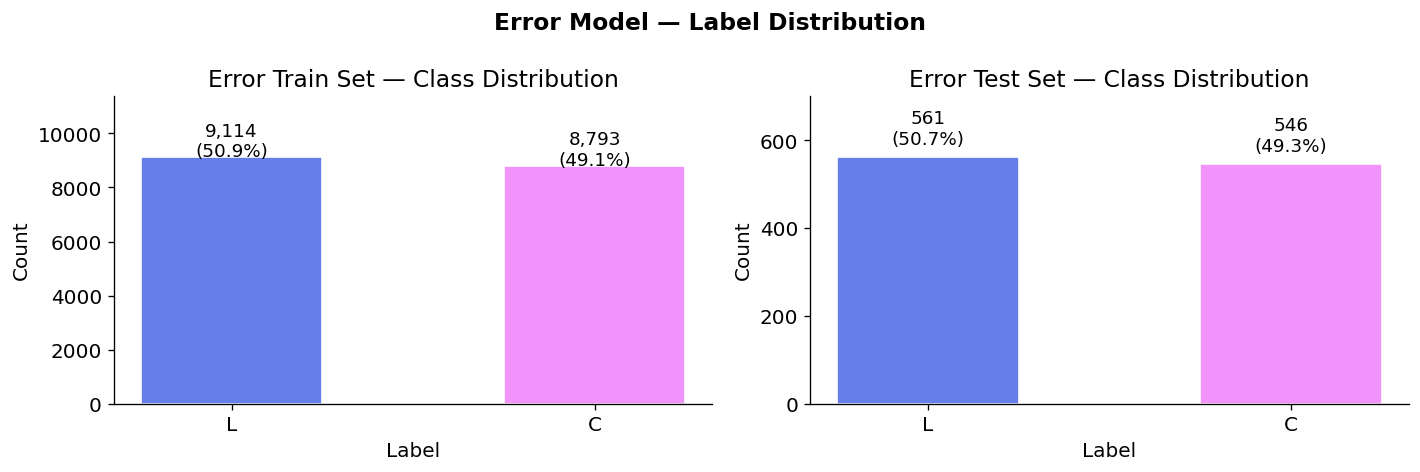

In [25]:
# ── Class distribution (error) ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (df_plot, title) in zip(axes, [
        (err_train_df, "Error Train Set"),
        (err_test_df,  "Error Test Set")]):
    counts = df_plot["label"].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=[C1, C2], edgecolor="white", width=0.5)
    ax.set_title(f"{title} — Class Distribution")
    ax.set_xlabel("Label"); ax.set_ylabel("Count")
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f"{val:,}\n({val/len(df_plot)*100:.1f}%)",
                ha="center", fontsize=11)
    ax.set_ylim(0, counts.max() * 1.25)
plt.suptitle("Error Model — Label Distribution", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_03_err_class_distribution.png", bbox_inches="tight")
plt.show()


In [26]:
# ── Normalise + encode + scale (error) ───────────────────────────────────
err_train_norm = normalize_pose(err_train_df)
err_test_norm  = normalize_pose(err_test_df)

err_le = LabelEncoder()
y_err_train = err_le.fit_transform(err_train_norm["label"].values)
y_err_test  = err_le.transform(err_test_norm["label"].values)
N_ERR_CLASSES = len(err_le.classes_)

print("Error label encoding:", dict(zip(err_le.classes_, err_le.transform(err_le.classes_))))
print("Classes:", err_le.classes_.tolist(), "| N_CLASSES:", N_ERR_CLASSES)

err_scaler = StandardScaler()
X_err_train = err_scaler.fit_transform(err_train_norm[FEATURE_COLS].values)
X_err_test  = err_scaler.transform(err_test_norm[FEATURE_COLS].values)

print(f"\nTrain — mean: {X_err_train.mean():+.5f} | std: {X_err_train.std():.5f}")
print(f"Test  — mean: {X_err_test.mean():+.5f}  | std: {X_err_test.std():.5f}")


Error label encoding: {'C': np.int64(0), 'L': np.int64(1)}
Classes: ['C', 'L'] | N_CLASSES: 2

Train — mean: -0.00000 | std: 1.00000
Test  — mean: +0.01032  | std: 0.89563


In [27]:
# ── Build PyG datasets (error) ────────────────────────────────────────────
err_train_dataset = build_graph_dataset(X_err_train, y_err_train, EDGE_INDEX)
err_test_dataset  = build_graph_dataset(X_err_test,  y_err_test,  EDGE_INDEX)

err_train_loader = DataLoader(err_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
err_test_loader  = DataLoader(err_test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

s = err_train_dataset[0]
print(f"data.x : {s.x.shape}  |  data.y : {s.y.item()}")
print(f"Train batches : {len(err_train_loader)}")
print(f"Test  batches : {len(err_test_loader)}")


data.x : torch.Size([13, 4])  |  data.y : 0
Train batches : 70
Test  batches : 5


In [28]:
# ── Train Error GCN ───────────────────────────────────────────────────────
err_model = LungeGCN(n_classes=N_ERR_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in err_model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")


Total trainable parameters: 68,642


In [29]:
err_history = train_model(
    err_model, err_train_loader, err_test_loader,
    name="LungeGCN-Error", epochs=EPOCHS
)


Training LungeGCN-Error on cuda ...
 Epoch  TrainLoss    ValLoss   TrainAcc     ValAcc
-------------------------------------------------------
     1     0.2049     0.0169     91.94%     99.64%
    10     0.0141     0.0192     99.46%     99.73%
    20     0.0075     0.0231     99.73%     99.73%
    30     0.0057     0.0237     99.78%     99.73%
    40     0.0049     0.0224     99.82%     99.73%
    50     0.0044     0.0237     99.86%     99.73%
    60     0.0051     0.0244     99.80%     99.73%
    70     0.0042     0.0239     99.87%     99.73%
    80     0.0052     0.0233     99.81%     99.82%
    90     0.0039     0.0233     99.85%     99.73%
   100     0.0045     0.0234     99.85%     99.73%
   110     0.0041     0.0236     99.85%     99.73%
   120     0.0039     0.0233     99.85%     99.73%

✅  Best val accuracy: 99.82%


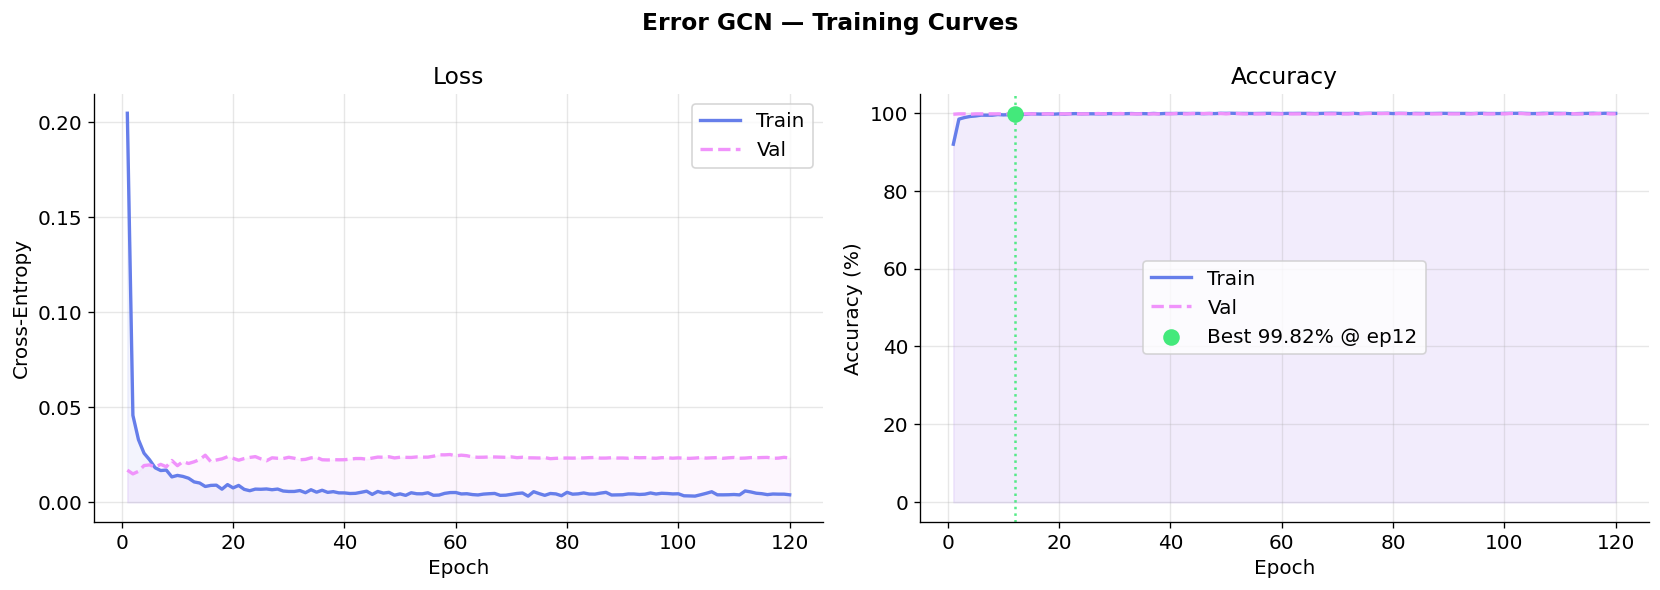

Saved: eval_err_01_training_curves.png


In [30]:
# ── Training curves (error) ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Error GCN — Training Curves", fontsize=14, fontweight="bold")

axes[0].plot(epochs_range, err_history["train_loss"], color=C1, lw=2, label="Train")
axes[0].plot(epochs_range, err_history["val_loss"],   color=C2, lw=2, ls="--", label="Val")
axes[0].fill_between(epochs_range, err_history["train_loss"], alpha=0.08, color=C1)
axes[0].fill_between(epochs_range, err_history["val_loss"],   alpha=0.08, color=C2)
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-Entropy")
axes[0].legend()

e_train_acc = [a*100 for a in err_history["train_acc"]]
e_val_acc   = [a*100 for a in err_history["val_acc"]]
axes[1].plot(epochs_range, e_train_acc, color=C1, lw=2, label="Train")
axes[1].plot(epochs_range, e_val_acc,   color=C2, lw=2, ls="--", label="Val")
axes[1].fill_between(epochs_range, e_train_acc, alpha=0.08, color=C1)
axes[1].fill_between(epochs_range, e_val_acc,   alpha=0.08, color=C2)

best_ep  = int(np.argmax(e_val_acc)) + 1
best_val = max(e_val_acc)
axes[1].axvline(best_ep, color=C4, lw=1.5, ls=":", alpha=0.9)
axes[1].scatter(best_ep, best_val, color=C4, s=80, zorder=5,
                label=f"Best {best_val:.2f}% @ ep{best_ep}")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("eval_err_01_training_curves.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: eval_err_01_training_curves.png")


In [31]:
# ── Error model evaluation on test set ───────────────────────────────────
_, err_acc, err_preds, err_probs, err_true = evaluate(
    err_model, err_test_loader, criterion_eval, DEVICE
)

err_metrics = {
    "Accuracy" : accuracy_score(err_true, err_preds),
    "F1 Score" : f1_score(err_true, err_preds, average="macro"),
    "Precision": precision_score(err_true, err_preds, average="macro"),
    "Recall"   : recall_score(err_true, err_preds, average="macro"),
}

print("Error GCN — Test Set Metrics:")
for k, v in err_metrics.items():
    print(f"  {k:12s}: {v*100:.2f}%")

print("\n── Full Classification Report ──")
print(classification_report(err_true, err_preds,
      target_names=[f"{c}" for c in err_le.classes_]))


Error GCN — Test Set Metrics:
  Accuracy    : 99.82%
  F1 Score    : 99.82%
  Precision   : 99.82%
  Recall      : 99.82%

── Full Classification Report ──
              precision    recall  f1-score   support

           C       1.00      1.00      1.00       546
           L       1.00      1.00      1.00       561

    accuracy                           1.00      1107
   macro avg       1.00      1.00      1.00      1107
weighted avg       1.00      1.00      1.00      1107



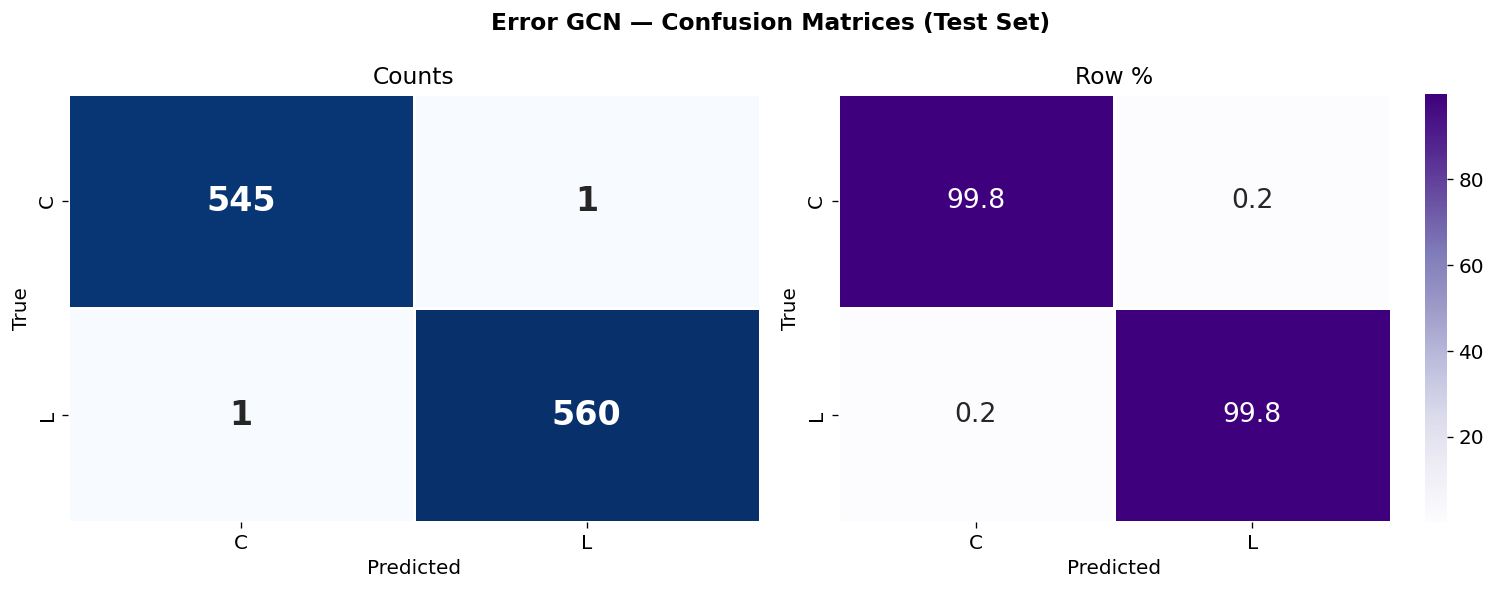

Saved: eval_err_02_confusion_matrix.png


In [32]:
# ── Confusion matrix (error) ──────────────────────────────────────────────
err_class_names = err_le.classes_
cm_e     = confusion_matrix(err_true, err_preds)
cm_e_pct = cm_e.astype(float) / cm_e.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Error GCN — Confusion Matrices (Test Set)", fontsize=14, fontweight="bold")

sns.heatmap(cm_e, annot=True, fmt="d", cmap="Blues",
            xticklabels=err_class_names, yticklabels=err_class_names,
            linewidths=1.5, ax=axes[0], cbar=False,
            annot_kws={"size": 20, "weight": "bold"})
axes[0].set_title("Counts"); axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

sns.heatmap(cm_e_pct, annot=True, fmt=".1f", cmap="Purples",
            xticklabels=err_class_names, yticklabels=err_class_names,
            linewidths=1.5, ax=axes[1], cbar=True,
            annot_kws={"size": 16})
axes[1].set_title("Row %"); axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig("eval_err_02_confusion_matrix.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: eval_err_02_confusion_matrix.png")


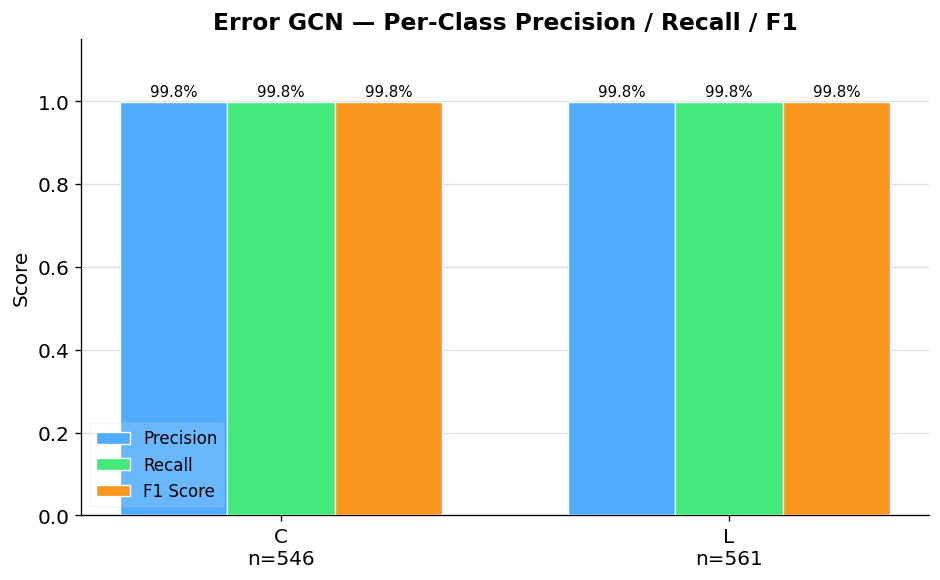

Saved: eval_err_03_per_class_metrics.png


In [33]:
# ── Per-class Precision / Recall / F1 (error) ────────────────────────────
prec_e, rec_e, f1_e, support_e = precision_recall_fscore_support(
    err_true, err_preds, labels=list(range(N_ERR_CLASSES)))

x = np.arange(N_ERR_CLASSES)
w = 0.24

fig, ax = plt.subplots(figsize=(8, 5))
for bars_data, offset, color, label in [
    (prec_e,  -w, colors[0], "Precision"),
    (rec_e,    0, colors[1], "Recall"),
    (f1_e,    +w, colors[2], "F1 Score"),
]:
    bars = ax.bar(x + offset, bars_data, w, color=color,
                  edgecolor="white", linewidth=0.8, label=label, zorder=3)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.008,
                f"{bar.get_height()*100:.1f}%", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{err_le.classes_[i]}\nn={support_e[i]}" for i in range(N_ERR_CLASSES)],
    fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Error GCN — Per-Class Precision / Recall / F1", fontweight="bold")
ax.legend(fontsize=10, framealpha=0.15)
ax.grid(axis="y", alpha=0.4, zorder=0)

plt.tight_layout()
plt.savefig("eval_err_03_per_class_metrics.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: eval_err_03_per_class_metrics.png")


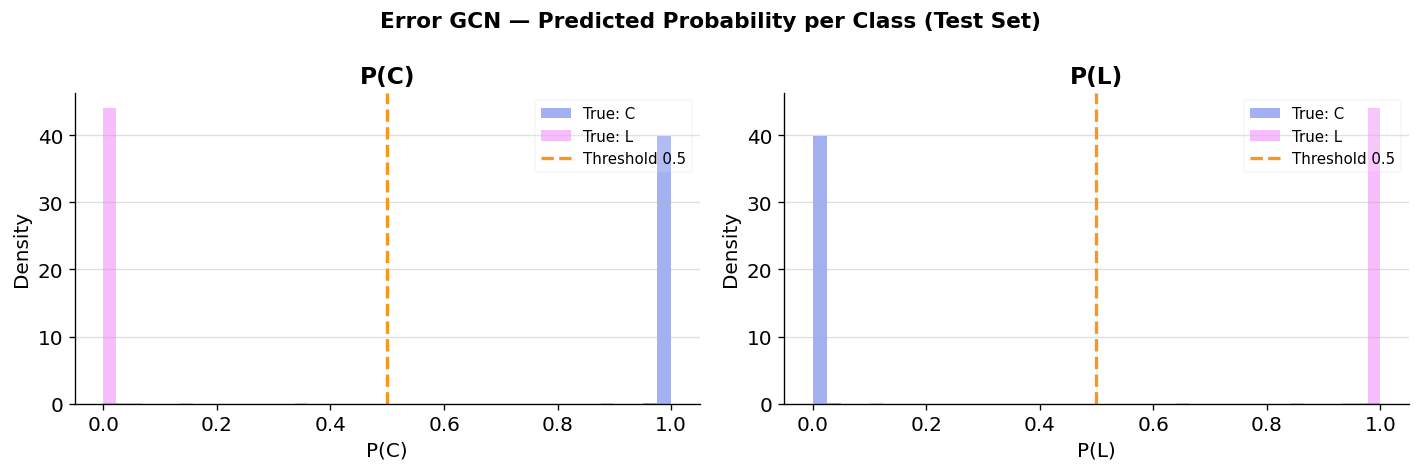

Saved: eval_err_04_prob_distributions.png


In [34]:
# ── Probability distributions (error) ────────────────────────────────────
fig, axes = plt.subplots(1, N_ERR_CLASSES, figsize=(12, 4))
fig.suptitle("Error GCN — Predicted Probability per Class (Test Set)",
             fontsize=13, fontweight="bold")

for cls_idx in range(N_ERR_CLASSES):
    ax = axes[cls_idx]
    for true_cls, color in enumerate([C1, C2]):
        mask = err_true == true_cls
        ax.hist(err_probs[mask, cls_idx], bins=40, alpha=0.6,
                color=color, label=f"True: {err_le.classes_[true_cls]}",
                edgecolor="none", density=True)
    ax.axvline(0.5, color="#f7971e", lw=2, ls="--", label="Threshold 0.5")
    ax.set_xlabel(f"P({err_le.classes_[cls_idx]})")
    ax.set_ylabel("Density")
    ax.set_title(f"P({err_le.classes_[cls_idx]})", fontweight="bold")
    ax.legend(fontsize=9, framealpha=0.15)
    ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig("eval_err_04_prob_distributions.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: eval_err_04_prob_distributions.png")


In [35]:
# ── Save Error model artifacts ────────────────────────────────────────────
torch.save(err_model.state_dict(), "lunge_err_gcn.pth")
print("✅  Saved: lunge_err_gcn.pth")

with open("lunge_err_gcn_scaler.pkl", "wb") as f:
    pickle.dump(err_scaler, f)
print("✅  Saved: lunge_err_gcn_scaler.pkl")

with open("lunge_err_gcn_label_encoder.pkl", "wb") as f:
    pickle.dump(err_le, f)
print("✅  Saved: lunge_err_gcn_label_encoder.pkl")

print()
print("Error label encoding:", dict(zip(err_le.classes_, err_le.transform(err_le.classes_))))
print("Files needed for inference: lunge_err_gcn.pth  +  lunge_err_gcn_scaler.pkl")


✅  Saved: lunge_err_gcn.pth
✅  Saved: lunge_err_gcn_scaler.pkl
✅  Saved: lunge_err_gcn_label_encoder.pkl

Error label encoding: {'C': np.int64(0), 'L': np.int64(1)}
Files needed for inference: lunge_err_gcn.pth  +  lunge_err_gcn_scaler.pkl


---
## 5. Combined Results Summary

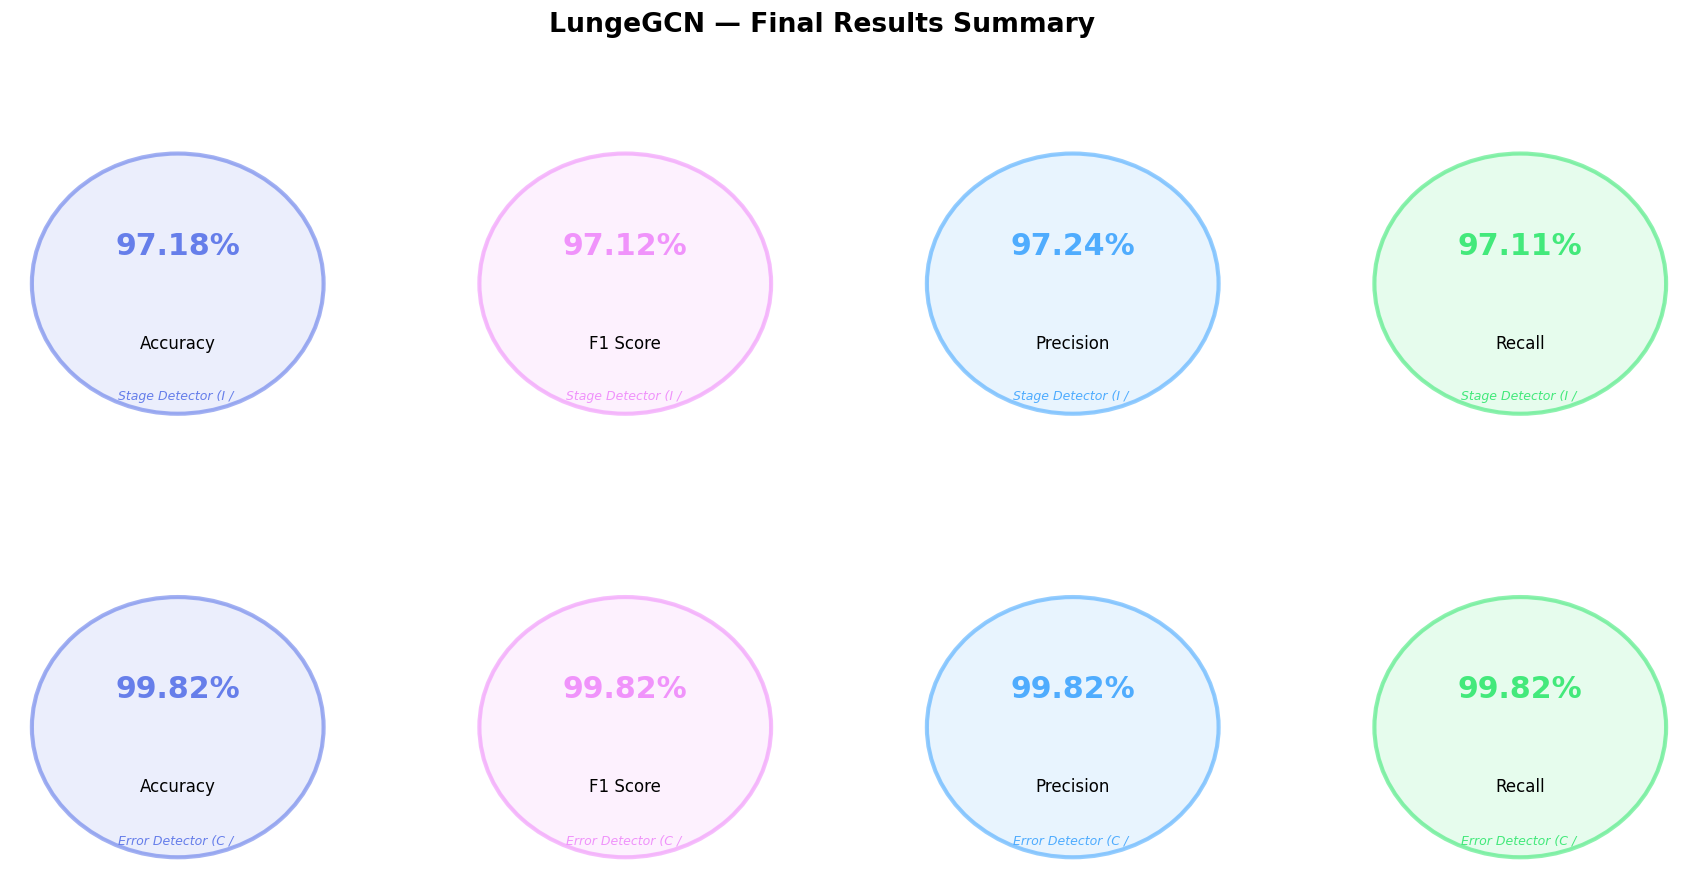

Saved: eval_combined_summary.png

  Metric           Stage (I/M/D)   Error (C/L)
-------------------------------------------------------
  Accuracy                97.18%        99.82%
  F1 Score                97.12%        99.82%
  Precision               97.24%        99.82%
  Recall                  97.11%        99.82%


In [36]:
# ── Final results summary dashboard ──────────────────────────────────────
metric_names  = ["Accuracy", "F1 Score", "Precision", "Recall"]
accent_colors = [C1, C2, C3, C4]

fig = plt.figure(figsize=(18, 8))
fig.suptitle("LungeGCN — Final Results Summary",
             fontsize=16, fontweight="bold", y=1.01)

gs = gridspec.GridSpec(2, 4, figure=fig, hspace=0.5, wspace=0.35)

for row, (model_name, metrics) in enumerate([
        ("Stage Detector (I / M / D)", stage_metrics),
        ("Error Detector (C / L)",     err_metrics)]):
    for col, (metric, color) in enumerate(zip(metric_names, accent_colors)):
        ax = fig.add_subplot(gs[row, col])
        val = metrics[metric]
        ax.add_patch(plt.Circle((0.5, 0.5), 0.44, color=color, alpha=0.13))
        ax.add_patch(plt.Circle((0.5, 0.5), 0.44, fill=False,
                                edgecolor=color, linewidth=2.5, alpha=0.6))
        ax.text(0.5, 0.63, f"{val*100:.2f}%",
                ha="center", va="center", fontsize=18,
                fontweight="bold", color=color)
        ax.text(0.5, 0.30, metric,
                ha="center", va="center", fontsize=10)
        ax.text(0.5, 0.12, model_name[:20],
                ha="center", va="center", fontsize=7.5,
                color=color, fontstyle="italic")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")

plt.savefig("eval_combined_summary.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: eval_combined_summary.png")

print("\n" + "="*55)
print(f"  {'Metric':14s}  {'Stage (I/M/D)':>14}  {'Error (C/L)':>12}")
print("-"*55)
for m in metric_names:
    s = stage_metrics[m]
    e = err_metrics[m]
    print(f"  {m:14s}  {s*100:>13.2f}%  {e*100:>11.2f}%")
print("="*55)


In [37]:
# ── Summary of all saved files ────────────────────────────────────────────
import os

saved_files = [
    "lunge_stage_gcn.pth",
    "lunge_stage_gcn_scaler.pkl",
    "lunge_stage_gcn_label_encoder.pkl",
    "lunge_err_gcn.pth",
    "lunge_err_gcn_scaler.pkl",
    "lunge_err_gcn_label_encoder.pkl",
]

print("── Saved model files ──────────────────────────────────────")
for fname in saved_files:
    exists = os.path.exists(fname)
    size   = os.path.getsize(fname) if exists else 0
    status = "✅" if exists else "❌"
    print(f"  {status}  {fname:45s}  {size/1024:.1f} KB")

print()
print("── Saved figures ──────────────────────────────────────────")
figs = sorted([f for f in os.listdir(".") if f.endswith(".png")])
for f in figs:
    size = os.path.getsize(f)
    print(f"  📊  {f:50s}  {size/1024:.0f} KB")


── Saved model files ──────────────────────────────────────
  ✅  lunge_stage_gcn.pth                            278.9 KB
  ✅  lunge_stage_gcn_scaler.pkl                     1.7 KB
  ✅  lunge_stage_gcn_label_encoder.pkl              0.2 KB
  ✅  lunge_err_gcn.pth                              278.6 KB
  ✅  lunge_err_gcn_scaler.pkl                       1.7 KB
  ✅  lunge_err_gcn_label_encoder.pkl                0.2 KB

── Saved figures ──────────────────────────────────────────
  📊  eval_combined_summary.png                           213 KB
  📊  eval_err_01_training_curves.png                     91 KB
  📊  eval_err_02_confusion_matrix.png                    48 KB
  📊  eval_err_03_per_class_metrics.png                   36 KB
  📊  eval_err_04_prob_distributions.png                  42 KB
  📊  eval_stage_01_training_curves.png                   123 KB
  📊  eval_stage_02_confusion_matrix.png                  60 KB
  📊  eval_stage_03_per_class_metrics.png                 48 KB
  📊  eval_stage